### Canadian Bike Network Data (Official)

8,899 segments with standardized classification

CANBICS classes (bike_path, protected_lane, etc.) - quality ratings!

Population data for each area (csd_population_2021)

Official classification of infrastructure quality

In [1]:
import geopandas as gpd

# Read the GeoPackage file
# Replace 'path_to_your_file.gpkg' with the actual file path
gdf = gpd.read_file('montreal_bike_network.gpkg')

# If the file contains multiple layers, you can specify one:
# gdf = gpd.read_file('path_to_your_file.gpkg', layer='layer_name')

# Display the first 5 rows of the data and the geometry
display(gdf.head(10))

# Check the coordinate reference system (important for accurate mapping)
print(gdf.crs)

,province_territory,municipality,source_data_id,record_id,source_class,source_class_secondary,canbics_class,surface_type,width_m,length_km,csdname,cmaname,csd_population_2021,geometry
0,qc,Montreal,None,fb0078a52fb168b7154d4ad8b95b82e6,piste cyclable en site propre,None,bike_path,None,NaN,0.0630,Kirkland,Montréal,19413.0,"MULTILINESTRING ((7609332.897 1231926.532, 760..."
1,qc,Montreal,None,dc2b4ec01d405e1d76fb6b7e87d086f8,piste cyclable en site propre,None,bike_path,None,NaN,0.0762,Dollard-Des Ormeaux,Montréal,48403.0,"MULTILINESTRING ((7615183.732 1238433.324, 761..."
2,qc,Montreal,None,4ed272ac27b6eba3dd24a3b9415b4a40,sentier polyvalent,None,gravel_trail,None,NaN,0.1155,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7616491.471 1239929.881, 761..."
3,qc,Montreal,None,0c369bee2e9470f2c891cbe21d098a9b,piste cyclable au niveau du trottoir,None,cycle_track,None,NaN,0.0082,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7625010.741 1234637.039, 762..."
4,qc,Montreal,None,c34134e3f7c6c517011462fa9955e18c,sentier polyvalent,None,gravel_trail,None,NaN,0.2389,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7608523.108 1239612.154, 760..."
5,qc,Montreal,None,c7efb686812f93a2eac73fea829b7325,piste cyclable en site propre,None,bike_path,None,NaN,0.2688,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7632767.805 1257300.338, 763..."
6,qc,Montreal,None,5840a95d6d3d47fb0449b28092972939,piste cyclable sur rue,Bollard,cycle_track,None,NaN,0.0343,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7622129.814 1248171.749, 762..."
7,qc,Montreal,None,a8d287b0d55bf4d2ca108fb8c89ef401,piste cyclable sur rue,Bollard,cycle_track,None,NaN,0.0709,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7622095.323 1248176.471, 762..."
8,qc,Montreal,None,506eeef1bc0040fc447eb236ab403e1c,sentier polyvalent,None,gravel_trail,None,NaN,0.0906,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7629358.619 1243454.764, 762..."
9,qc,Montreal,None,8ae5e10825c0fe150986af0f61e1b3e6,piste cyclable en site propre,None,bike_path,None,NaN,0.2927,Montréal,Montréal,1762949.0,"MULTILINESTRING ((7626378.616 1235598.629, 762..."


EPSG:3347


In [2]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8899 entries, 0 to 8898
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   province_territory      8899 non-null   object  
 1   municipality            8899 non-null   object  
 2   source_data_id          0 non-null      object  
 3   record_id               8899 non-null   object  
 4   source_class            8899 non-null   object  
 5   source_class_secondary  2007 non-null   object  
 6   canbics_class           8899 non-null   object  
 7   surface_type            0 non-null      object  
 8   width_m                 0 non-null      float64 
 9   length_km               8899 non-null   float64 
 10  csdname                 8899 non-null   object  
 11  cmaname                 8843 non-null   object  
 12  csd_population_2021     8899 non-null   float64 
 13  geometry                8899 non-null   geometry
dtypes: float64(3), g

### OSM Cycleway Data (Community-Mapped)
12,585 segments with real-world names

Actual REV routes identified (Rachel, Saint-Denis, etc.)

Connectivity information (network graph structure)

Recent community updates

In [4]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# Configure osmnx
ox.settings.log_console = True
ox.settings.use_cache = True

# Get the entire street network for Montreal
print("Downloading Montreal street network...")
G = ox.graph_from_place("Montreal, Canada", network_type='all')

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

print(f"Retrieved {len(nodes)} nodes and {len(edges)} edges")
print("Columns in edges data:", edges.columns.tolist())

Retrieved 215186 nodes and 626576 edges
Columns in edges data: ['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'width', 'bridge', 'access', 'tunnel', 'ref', 'service', 'junction', 'est_width']


Street types in Montreal:
highway
footway               336247
service               139443
residential            74396
tertiary               20242
secondary              19788
cycleway               12585
path                    5106
unclassified            4778
primary                 3746
[steps, footway]        2760
[service, footway]      1332
pedestrian              1109
secondary_link           642
[path, footway]          546
steps                    492
Name: count, dtype: int64


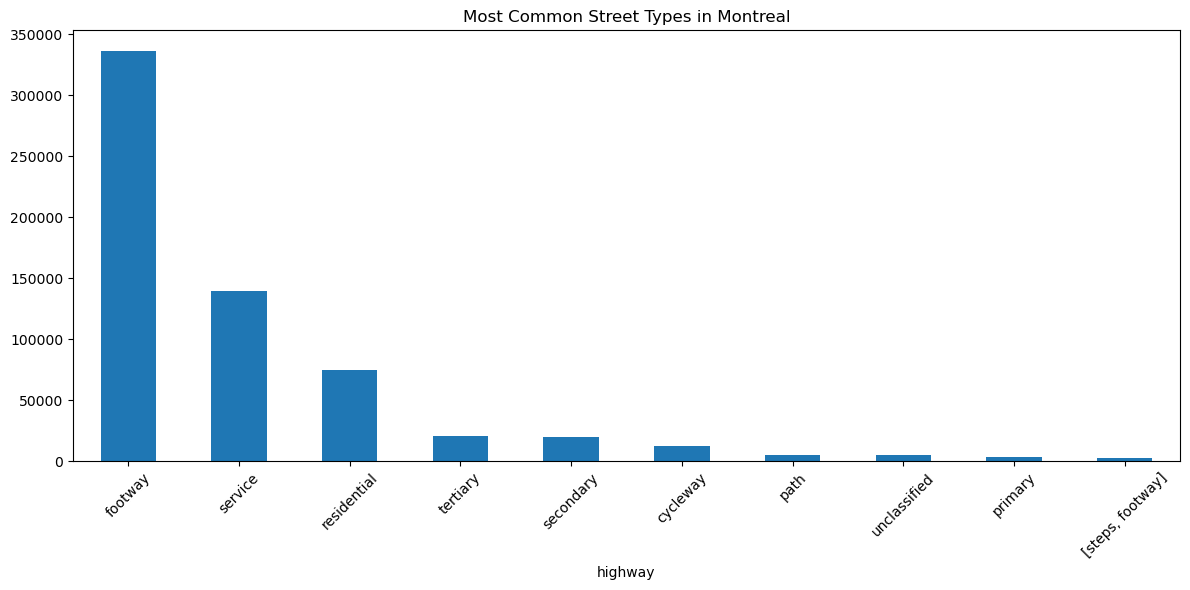

In [5]:
# Analyze what types of streets we have
print("Street types in Montreal:")
street_types = edges['highway'].value_counts()
print(street_types.head(15))

# Plot the distribution
plt.figure(figsize=(12, 6))
street_types.head(10).plot(kind='bar')
plt.title('Most Common Street Types in Montreal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Let's first see what columns we have and sample data
print("All columns in edges data:")
print(edges.columns.tolist())

# Check for any cycling-related columns
cycling_columns = [col for col in edges.columns if 'cycle' in col.lower() or 'bike' in col.lower()]
print(f"\nCycling-related columns: {cycling_columns}")

# Let's look at sample data from different street types
print("\nSample data for different street types:")
sample_street_types = ['residential', 'primary', 'secondary', 'tertiary', 'path', 'footway']

for street_type in sample_street_types:
    sample_data = edges[edges['highway'] == street_type].head(1)
    if len(sample_data) > 0:
        print(f"\n--- {street_type.upper()} roads sample ---")
        # Show only the most relevant columns
        relevant_cols = ['osmid', 'highway', 'name', 'length', 'oneway', 'lanes', 'maxspeed']
        # Add any cycling columns we found
        relevant_cols.extend(cycling_columns)
        display_cols = [col for col in relevant_cols if col in sample_data.columns]
        print(sample_data[display_cols].iloc[0])

All columns in edges data:
['osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'geometry', 'width', 'bridge', 'access', 'tunnel', 'ref', 'service', 'junction', 'est_width']

Cycling-related columns: []

Sample data for different street types:

--- RESIDENTIAL roads sample ---
osmid                 143310627
highway             residential
name        Avenue Henri-Julien
length                 6.470371
oneway                     True
lanes                         1
maxspeed                     30
Name: (26232418, 1653821632, 0), dtype: object

--- PRIMARY roads sample ---
osmid                  465408857
highway                  primary
name        Rue Sherbrooke Ouest
length                  7.676937
oneway                     False
lanes                          4
maxspeed                      50
Name: (26233222, 8010557506, 0), dtype: object

--- SECONDARY roads sample ---
osmid                      971673239
highway                    secondary
name    

In [10]:
# First, let's examine the maxspeed column more carefully
print("Maxspeed value types:")
print(edges['maxspeed'].value_counts().head(20))

print("\nLanes value types:")
print(edges['lanes'].value_counts().head(10))

Maxspeed value types:
maxspeed
30           67910
40           24933
50           18401
20             772
70             432
60             284
15             265
10             238
100            189
[40, 30]        85
25              77
5               32
80              23
8               20
[70, 50]        17
[40, 50]        16
[30, 50]        15
78              12
[70, 100]        9
[20, 30]         5
Name: count, dtype: int64

Lanes value types:
lanes
2         71923
1         24684
3          7629
4          7186
5           922
[2, 3]      652
6           624
[3, 4]      457
[2, 1]      265
[2, 4]       85
Name: count, dtype: int64


In [14]:
# Let's examine the actual cycleway data you have
cycleway_data = edges[edges['highway'] == 'cycleway']

print(f"You have {len(cycleway_data):,} dedicated cycleway segments!")
print("\nSample of your cycleway data:")
print(cycleway_data[['name', 'length', 'oneway']].head(10))

# Check if these have names (likely the existing REV)
named_cycleways = cycleway_data[cycleway_data['name'].notna()]
print(f"\nNamed cycleways (likely REV): {len(named_cycleways)}")
if len(named_cycleways) > 0:
    print("Cycleway names:")
    print(named_cycleways['name'].value_counts().head(10))

You have 12,585 dedicated cycleway segments!

Sample of your cycleway data:
                                   name      length  oneway
u        v           key                                   
26233369 12866899368 0     Place Royale   13.411354   False
26233376 1432604617  0              NaN   13.121102   False
29239079 6772820967  0              NaN    8.354708   False
29794303 4171775445  0              NaN    7.475883   False
30452955 10839975544 0    Piste du parc   14.100671   False
         8387919428  0    Piste du parc    3.037472   False
30452956 8016511670  0    Piste du parc   17.487434   False
         209046809   0              NaN   61.302694   False
         1634749427  0    Piste du parc  192.731811   False
30453004 1634749428  0              NaN   22.256816   False

Named cycleways (likely REV): 8728
Cycleway names:
name
Rue de Bellechasse                468
Piste cyclable des Berges         452
Rue Rachel Est                    396
Boulevard de Pierrefonds         

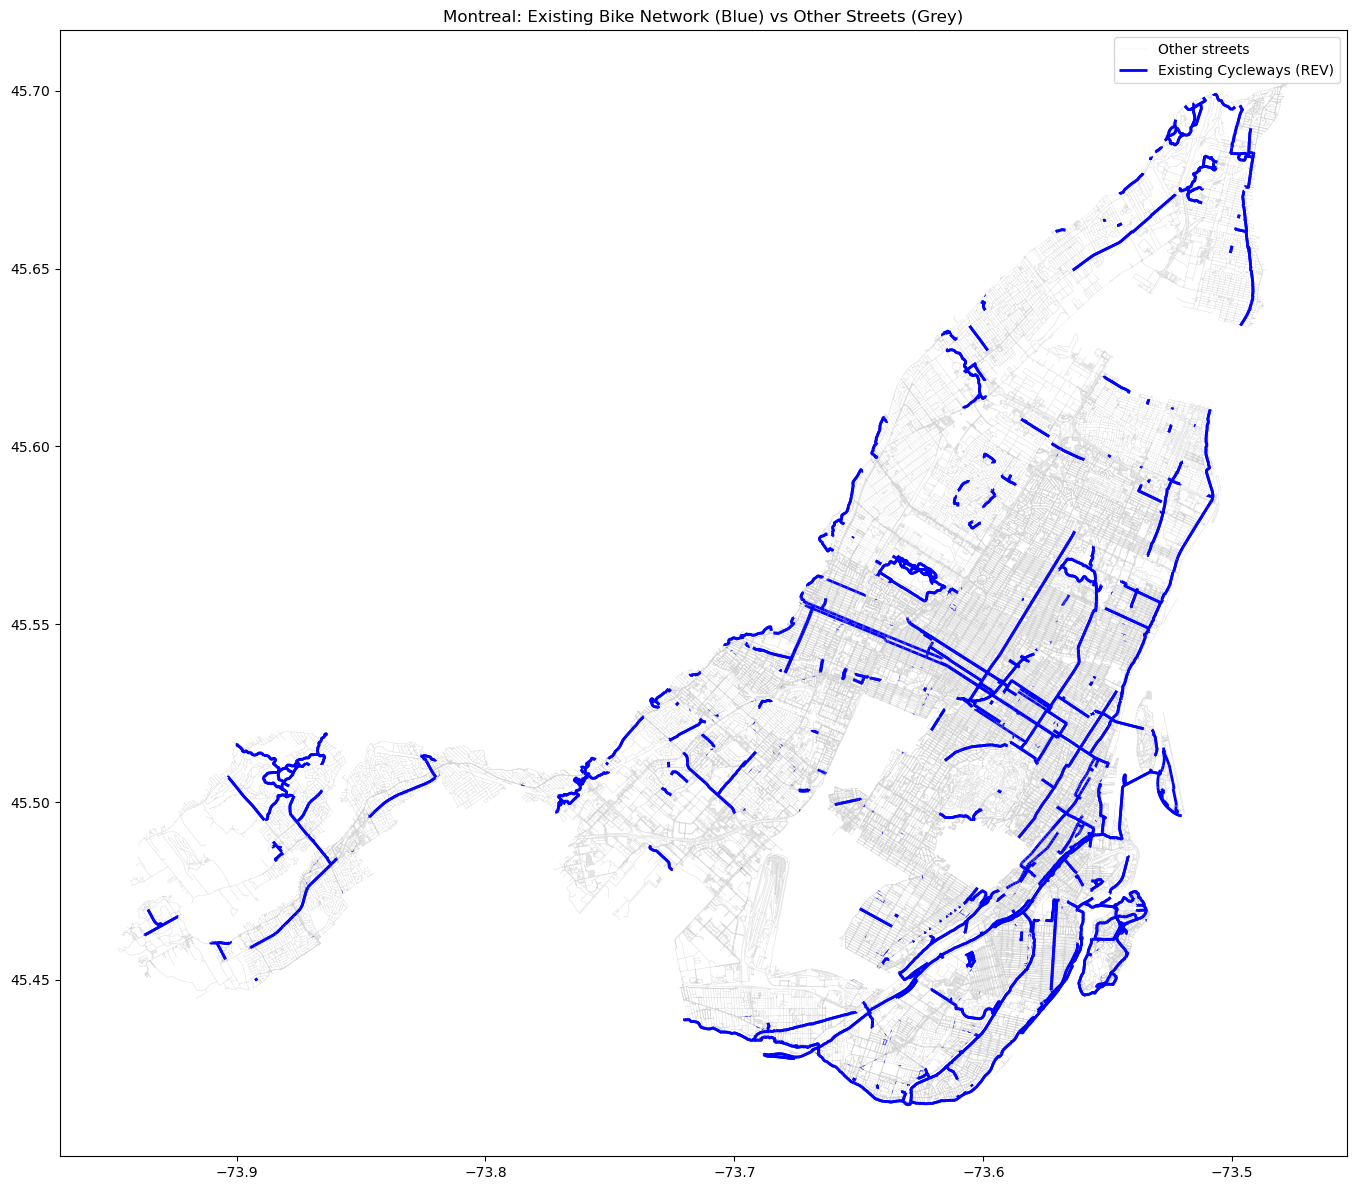

In [15]:
# Plot the existing bike network vs all other streets
fig, ax = plt.subplots(figsize=(15, 12))

# Plot all other streets in light grey
other_streets = edges[edges['highway'] != 'cycleway']
other_streets.plot(ax=ax, color='lightgrey', linewidth=0.3, alpha=0.5, label='Other streets')

# Plot existing cycleways in bright blue (the current REV)
cycleway_data.plot(ax=ax, color='blue', linewidth=2, label='Existing Cycleways (REV)')

ax.legend()
ax.set_title('Montreal: Existing Bike Network (Blue) vs Other Streets (Grey)')
plt.tight_layout()
plt.show()

In [17]:
# You can now cross-validate and enrich your data
print("DATA INTEGRATION OPPORTUNITIES:")
print(f"Official records: {len(gdf):,} segments")
print(f"OSM community data: {len(cycleway_data):,} segments")
print("→ Use OSM to fill gaps in official data")
print("→ Use official data for quality classification")

DATA INTEGRATION OPPORTUNITIES:
Official records: 8,899 segments
OSM community data: 12,585 segments
→ Use OSM to fill gaps in official data
→ Use official data for quality classification


### BIXI Data

In [18]:
import pandas as pd

bixi_df = pd.read_csv('/Users/fayewu/Downloads/DonneesOuvertes_2025-10-28-1600.csv')
bixi_df.head()

,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Clark / Evans,Ville-Marie,45.511099,-73.567843,Bennett / Ontario,Mercier - Hochelaga-Maisonneuve,45.555551,-73.540102,1758162829092,1.758165e+12
1,Clark / Evans,Ville-Marie,45.511099,-73.567843,Garnier / Gilford,Le Plateau-Mont-Royal,45.532507,-73.580161,1758140652852,1.758142e+12
2,Clark / Evans,Ville-Marie,45.511099,-73.567843,Dorion / Ontario,Ville-Marie,45.526991,-73.558212,1758160206063,1.758161e+12
3,Clark / Evans,Ville-Marie,45.511099,-73.567843,Marie-Anne / Christophe-Colomb,Le Plateau-Mont-Royal,45.527023,-73.576773,1758146805772,1.758148e+12
4,Clark / Evans,Ville-Marie,45.511099,-73.567843,Lambert-Closse / de Maisonneuve,Ville-Marie,45.490925,-73.584996,1758141794832,1.758143e+12
